In [1]:
from IPython.display import clear_output

In [2]:
# %pip install accelerate
# %pip install bitsandbytes
# 
# clear_output()

# Content

In this notebook, we will use the multi-model model llava.
Llava can take image along with text as input and can answer questions or chat about the image.

We'll use huggingface to download and infer the model

In [1]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
import torch
from PIL import Image
import requests

2025-03-15 21:49:55.616523: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-15 21:49:55.704270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742064595.734562   41917 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742064595.745822   41917 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-15 21:49:55.806477: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
device

'cuda'

### Downloading the model

In [4]:
model_id = 'llava-hf/llava-v1.6-mistral-7b-hf'

processor = LlavaNextProcessor.from_pretrained(model_id)

model = LlavaNextForConditionalGeneration.from_pretrained(model_id,
                                                          torch_dtype=torch.float16,
                                                          low_cpu_mem_usage=True,
                                                          load_in_4bit=True)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

### Let's try an image

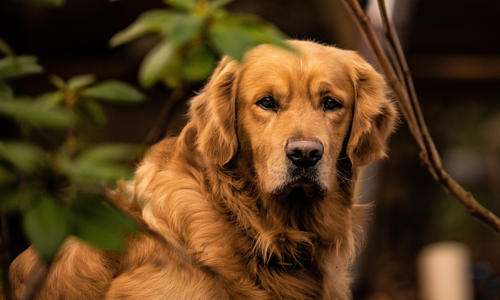

In [5]:
url = "https://cdn.pixabay.com/photo/2022/02/06/14/06/dog-6997211_1280.jpg"
image = Image.open(requests.get(url, stream=True).raw)

image = image.resize((500, 300))
image

In [6]:
prompt = """[INST] <image>\n Briefly summarize the contents of an image.
            Also explain the appearance of the main subject of the image. [/INST]"""

inputs = processor(prompt, image, return_tensors="pt").to(device)

You may have used the wrong order for inputs. `images` should be passed before `text`. The `images` and `text` inputs will be swapped. This behavior will be deprecated in transformers v4.47.


In [7]:
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=500)
print(processor.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
/home/ali/.virtualenvs/PyTorchENV/lib/python3.10/site-packages/bitsandbytes/nn/modules.py:451: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


[INST]  
 Briefly summarize the contents of an image.
            Also explain the appearance of the main subject of the image. [/INST] The image features a golden retriever dog with a rich, golden-brown coat. The dog is looking directly at the camera, giving a sense of engagement with the viewer. The dog's fur appears soft and well-groomed. The background is blurred, but it seems to be an outdoor setting with greenery, possibly a garden or park, which suggests a peaceful and natural environment. The focus is on the dog, making it the main subject of the image. 


### Let's try another

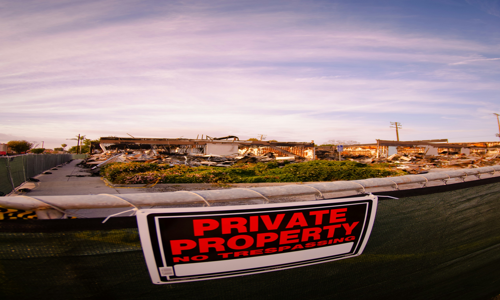

In [9]:
url = "https://images.unsplash.com/photo-1618504063109-5a9ba44df100?q=80&w=2536&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image = Image.open(requests.get(url, stream=True).raw)

image = image.resize((500, 300))
image

In [10]:
prompt = "[INST] <image> What's the main message in this image?[/INST]"

inputs = processor(prompt, image, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=500)

print(processor.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST]   What's the main message in this image?[/INST] The main message in this image is that the area is private property and no trespassing is allowed. The sign is placed on a fence, which is likely to be a barrier to prevent unauthorized access to the property. The background shows a dilapidated structure, suggesting that the property may be abandoned or in a state of disrepair. 


In [11]:
prompt = "[INST] <image> What color is the fence and what color is the text in the sign?[/INST]"

inputs = processor(prompt, image, return_tensors="pt").to(device)

with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=500)

print(processor.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST]   What color is the fence and what color is the text in the sign?[/INST] The fence in the image is green. The sign has red text. 


In [13]:
url = "https://i.imgur.com/gTjdYqm.jpeg"
image = Image.open(requests.get(url, stream=True).raw)

image = image.resize((500, 300))
image

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7f0a52817dd0>